# Study 1 -- MET-AI Interventions: Full Analysis

This notebook replicates the confirmatory analysis plan for Study 1 of the
MET-AI Interventions project.  925 Prolific participants solved 12
four-option planning/organising problems with an AI chat assistant and rated
their confidence (0-100) after each problem.  Five between-subjects
conditions were tested:

| Condition | Label | Wave |
|-----------|-------|------|
| `ai` | AI (baseline) | 1 + 2 |
| `ai-reliability` | Reliability cards | 1 |
| `alternatives` | Alternatives | 2 |
| `pause-points` | Pause points | 2 |
| `reflection-task` | Reflection task | 2 |

The analysis proceeds in 13 numbered steps, from data loading through
confirmatory hypothesis testing and sensitivity checks.

---
## Step 1 -- Setup

Import libraries, define constants, colour palettes, and reusable utility
functions that the rest of the notebook relies on.

In [1]:
# ---- imports ----------------------------------------------------------------
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    import pingouin as pg
    HAS_PINGOUIN = True
    print("pingouin version:", pg.__version__)
except ImportError:
    HAS_PINGOUIN = False
    print("pingouin not available -- falling back to scipy-only tests")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# ---- paths ------------------------------------------------------------------
NOTEBOOK_DIR = Path("/home/user/MET_AI_Interventions/data_analysis/deep_analysis/final_data")
OUTPUT_DIR   = NOTEBOOK_DIR / "notebook_analysis_output"
DATA_DIR     = Path("/home/user/MET_AI_Interventions/data_analysis/results/data/final_data")

# ---- condition constants ----------------------------------------------------
COND_ORDER   = ["ai", "ai-reliability", "alternatives", "pause-points", "reflection-task"]
COND_LABELS  = {
    "ai":              "AI (baseline)",
    "ai-reliability":  "Reliability cards",
    "alternatives":    "Alternatives",
    "pause-points":    "Pause points",
    "reflection-task": "Reflection task",
}
COND_COLOURS = {
    "ai":              "#2a78d6",
    "ai-reliability":  "#eb6834",
    "alternatives":    "#1baf7a",
    "pause-points":    "#eda100",
    "reflection-task": "#e87ba4",
}

# ---- matplotlib defaults ----------------------------------------------------
plt.rcParams.update({
    "figure.figsize":     (10, 5),
    "figure.dpi":         120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     12,
})
sns.set_style("white")

%matplotlib inline

# ---- utility functions ------------------------------------------------------
def sig_stars(p):
    """Return significance stars for a p-value."""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.1:   return "."
    return " "


def fmt_p(p):
    """Format a p-value for display."""
    return "< .001" if p < .001 else f"{p:.3f}"


def hedges_g(x1, x2):
    """Hedges' g with small-sample correction."""
    n1, n2 = len(x1), len(x2)
    s_pooled = np.sqrt(((n1 - 1) * np.var(x1, ddof=1) +
                         (n2 - 1) * np.var(x2, ddof=1)) / (n1 + n2 - 2))
    if s_pooled == 0:
        return 0.0
    d = (np.mean(x1) - np.mean(x2)) / s_pooled
    correction = 1 - 3 / (4 * (n1 + n2) - 9)
    return d * correction


def hedges_g_ci(x1, x2, alpha=0.05):
    """Hedges' g with 95% CI."""
    g = hedges_g(x1, x2)
    n1, n2 = len(x1), len(x2)
    se = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2)))
    z = scipy.stats.norm.ppf(1 - alpha / 2)
    return g, g - z * se, g + z * se


def auroc2(conf, correct):
    """Type-2 AUROC: P(conf_correct > conf_incorrect)."""
    hi = conf[correct == 1]
    lo = conf[correct == 0]
    if len(hi) == 0 or len(lo) == 0:
        return np.nan
    from scipy.stats import rankdata
    combined = np.concatenate([hi, lo])
    ranks = rankdata(combined)
    u = np.sum(ranks[:len(hi)]) - len(hi) * (len(hi) + 1) / 2
    return u / (len(hi) * len(lo))


def welch_anova_scipy(groups):
    """One-way Welch ANOVA via scipy (no homogeneity assumption)."""
    F, p = scipy.stats.f_oneway(*groups)
    return F, p


def pairwise_welch(df, dv, groupvar, groups):
    """All pairwise Welch t-tests with Hedges' g and 95% CI.
    Returns a DataFrame sorted by condition pair."""
    rows = []
    for i, g1 in enumerate(groups):
        for g2 in groups[i + 1:]:
            x1 = df.loc[df[groupvar] == g1, dv].dropna()
            x2 = df.loc[df[groupvar] == g2, dv].dropna()
            t, p = scipy.stats.ttest_ind(x1, x2, equal_var=False)
            g, lo, hi = hedges_g_ci(x1.values, x2.values)
            rows.append({
                "group1": g1, "group2": g2,
                "n1": len(x1), "n2": len(x2),
                "mean1": x1.mean(), "mean2": x2.mean(),
                "t": t, "p": p, "sig": sig_stars(p),
                "g": g, "g_lo": lo, "g_hi": hi,
            })
    out = pd.DataFrame(rows)
    return out


print("Setup complete.")

pingouin version: 0.6.1
Setup complete.


---
## Step 2 -- Load the data

We load two data sources:

1. **Participant-level CSV** (`participant_metrics.csv`) -- one row per
   participant with pre-computed summary variables (scores, confidence
   indices, questionnaire scales, demographics, exclusion flags).
2. **Trial-level JSON** files (one per condition) -- these contain the raw
   answer-by-answer results needed for item-level metacognition analyses.
   We reshape them into a long DataFrame with columns `pid`, `condition`,
   `item`, `correct`, `confidence`, `conf01`.

In [2]:
# ---- participant-level data -------------------------------------------------
df_all = pd.read_csv(OUTPUT_DIR / "participant_metrics.csv")
print(f"Loaded participant_metrics.csv: {df_all.shape[0]} rows x {df_all.shape[1]} columns")
print()
print("Condition counts (full sample):")
print(df_all["condition"].value_counts().reindex(COND_ORDER).to_frame("n"))

Loaded participant_metrics.csv: 925 rows x 77 columns

Condition counts (full sample):
                   n
condition           
ai               189
ai-reliability   184
alternatives     183
pause-points     184
reflection-task  185


In [3]:
# ---- trial-level data from JSON ---------------------------------------------
COND_FILES = {
    "ai":              "ai.json",
    "ai-reliability":  "ai_reliability.json",
    "alternatives":    "alternatives.json",
    "pause-points":    "pause_points.json",
    "reflection-task": "reflection_task.json",
}
MAIN_TASKS = [str(t) for t in range(6, 18)]  # tasks 6-17 are the 12 main problems

trial_rows = []
for cond, fname in COND_FILES.items():
    with open(DATA_DIR / fname) as f:
        data = json.load(f)
    for p in data["participants"]:
        pid = p["participantId"]
        for tk in MAIN_TASKS:
            ans_key = f"{tk}.1"
            conf_key = f"{tk}.2"
            correct = p["answerResults"].get(ans_key, None)
            conf_resp = p["tasks"].get(tk, {}).get("responses", {}).get(conf_key, {})
            confidence = conf_resp.get("answer", None)
            if correct is not None and confidence is not None:
                trial_rows.append({
                    "pid": pid,
                    "condition": cond,
                    "item": int(tk),
                    "correct": int(correct),
                    "confidence": float(confidence),
                })

trials = pd.DataFrame(trial_rows)
trials["conf01"] = trials["confidence"] / 100.0
print(f"\nTrial-level DataFrame: {trials.shape[0]} rows ({trials['pid'].nunique()} participants x up to 12 items)")
print(trials.groupby("condition")["pid"].nunique().reindex(COND_ORDER).to_frame("n_participants"))


Trial-level DataFrame: 9990 rows (925 participants x up to 12 items)
                 n_participants
condition                      
ai                          189
ai-reliability              184
alternatives                183
pause-points                184
reflection-task             185


---
## Step 3 -- Exclusions

The CSV carries pre-computed exclusion flags.  The primary exclusion
criterion (`exclude_primary`) combines:

- **Attention failures**: failed 2 or more of 4 embedded attention checks.
- **Speed**: completed the study in under 10 minutes.
- **Manual exclusion**: flagged during data cleaning.

We filter to `exclude_primary == False` for all subsequent analyses.

In [4]:
# ---- exclusion funnel -------------------------------------------------------
funnel = pd.DataFrame({
    "Criterion": [
        "Total recruited",
        "Excluded: attention (>= 2 failed)",
        "Excluded: too fast (< 10 min)",
        "Excluded: manual",
        "Excluded: primary (union)",
        "Analysis sample",
    ],
    "n": [
        len(df_all),
        df_all["exclude_attention"].sum(),
        df_all["exclude_fast"].sum(),
        df_all["exclude_manual"].sum(),
        df_all["exclude_primary"].sum(),
        (~df_all["exclude_primary"]).sum(),
    ],
})
print("Exclusion funnel:")
print(funnel.to_string(index=False))

Exclusion funnel:
                        Criterion   n
                  Total recruited 925
Excluded: attention (>= 2 failed)   7
    Excluded: too fast (< 10 min)   1
                 Excluded: manual  13
        Excluded: primary (union)   8
                  Analysis sample 917


In [5]:
# ---- apply exclusion --------------------------------------------------------
df = df_all[df_all["exclude_primary"] == False].copy()
df["condition"] = pd.Categorical(df["condition"], categories=COND_ORDER, ordered=True)
print(f"\nAnalysis sample: {len(df)} participants")
print()
print("Condition counts (analysis sample):")
print(df["condition"].value_counts().sort_index().to_frame("n"))

# Also filter trial-level data to match
analysis_pids = set(df["participant_id"])
trials = trials[trials["pid"].isin(analysis_pids)].copy()
print(f"\nTrial-level data after exclusion: {trials.shape[0]} rows, {trials['pid'].nunique()} participants")


Analysis sample: 917 participants

Condition counts (analysis sample):
                   n
condition           
ai               187
ai-reliability   182
alternatives     181
pause-points     184
reflection-task  183

Trial-level data after exclusion: 9906 rows, 917 participants


---
## Step 4 -- Add outcome variables

We derive two additional columns:

- `diffobjper`: the signed gap between perceived performance (`post_with_ai`,
  participants' post-task estimate of how many they got right out of 12) and
  actual performance (`actual_score`).  Positive values mean overestimation.
- `pc_obj`: proportion correct (actual_score / 12).
- `pc_per`: proportion perceived correct (post_with_ai / 12).

In [6]:
df["diffobjper"] = df["post_with_ai"] - df["actual_score"]
df["pc_obj"]     = df["actual_score"] / 12
df["pc_per"]     = df["post_with_ai"] / 12

print("Derived variable descriptives:")
desc = df[["actual_score", "post_with_ai", "diffobjper", "pc_obj", "pc_per"]].describe().round(3)
print(desc.to_string())

Derived variable descriptives:
       actual_score  post_with_ai  diffobjper   pc_obj   pc_per
count       917.000       917.000     917.000  917.000  917.000
mean          5.194         8.514       3.320    0.433    0.709
std           1.773         2.495       2.861    0.148    0.208
min           1.000         0.000      -6.000    0.083    0.000
25%           4.000         7.000       1.000    0.333    0.583
50%           5.000         9.000       4.000    0.417    0.750
75%           6.000        10.000       5.000    0.500    0.833
max          11.000        12.000      11.000    0.917    1.000


---
## Step 5 -- Demographics

Descriptive statistics for the analysis sample: age, gender, education,
English fluency, and AI usage frequency.  These inform whether the sample
is representative and whether any demographic imbalance across conditions
might confound the results.

In [7]:
# ---- age --------------------------------------------------------------------
print("Age:")
print(df["age"].describe().round(1).to_string())
print()

# ---- gender -----------------------------------------------------------------
print("Gender:")
gender_tab = df["gender"].value_counts().to_frame("n")
gender_tab["pct"] = (gender_tab["n"] / len(df) * 100).round(1)
print(gender_tab.to_string())
print()

# ---- education --------------------------------------------------------------
print("Education:")
edu_tab = df["education"].value_counts().to_frame("n")
edu_tab["pct"] = (edu_tab["n"] / len(df) * 100).round(1)
print(edu_tab.to_string())
print()

# ---- fluency ----------------------------------------------------------------
print("English fluency:")
flu_tab = df["fluency"].value_counts().to_frame("n")
flu_tab["pct"] = (flu_tab["n"] / len(df) * 100).round(1)
print(flu_tab.to_string())
print()

# ---- AI use -----------------------------------------------------------------
print("AI use frequency:")
ai_tab = df["ai_use_label"].value_counts().to_frame("n")
ai_tab["pct"] = (ai_tab["n"] / len(df) * 100).round(1)
print(ai_tab.to_string())

Age:
count    917.0
mean      35.7
std       10.9
min       18.0
25%       28.0
50%       34.0
75%       42.0
max       78.0

Gender:
                          n   pct
gender                           
Woman                   466  50.8
Man                     442  48.2
Non-binary                5   0.5
Prefer not to disclose    4   0.4

Education:
                                                      n   pct
education                                                    
Lower tertiary education degree (Bachelor's level)  407  44.4
Higher tertiary education degree (Master's level)   217  23.7
Upper secondary school / High school                140  15.3
Vocational college degree                           118  12.9
Doctoral degree                                      31   3.4
Basic education / Middle school                       4   0.4

English fluency:
                           n   pct
fluency                           
Native English speaker   795  86.7
Fully fluent             115  1

In [8]:
# ---- demographics by condition ----------------------------------------------
print("Age by condition:")
age_cond = df.groupby("condition", observed=False)["age"].agg(["mean", "std", "min", "max"]).round(1)
print(age_cond.to_string())
print()

print("Gender by condition:")
gender_cond = pd.crosstab(df["condition"], df["gender"])
print(gender_cond.to_string())

Age by condition:
                 mean   std   min   max
condition                              
ai               36.3  11.1  18.0  67.0
ai-reliability   35.6  10.8  18.0  75.0
alternatives     35.8  10.7  18.0  78.0
pause-points     35.0  10.8  19.0  72.0
reflection-task  35.7  11.2  18.0  63.0

Gender by condition:
gender           Man  Non-binary  Prefer not to disclose  Woman
condition                                                      
ai                94           1                       1     91
ai-reliability    96           1                       1     84
alternatives      82           2                       1     96
pause-points      85           1                       1     97
reflection-task   85           0                       0     98


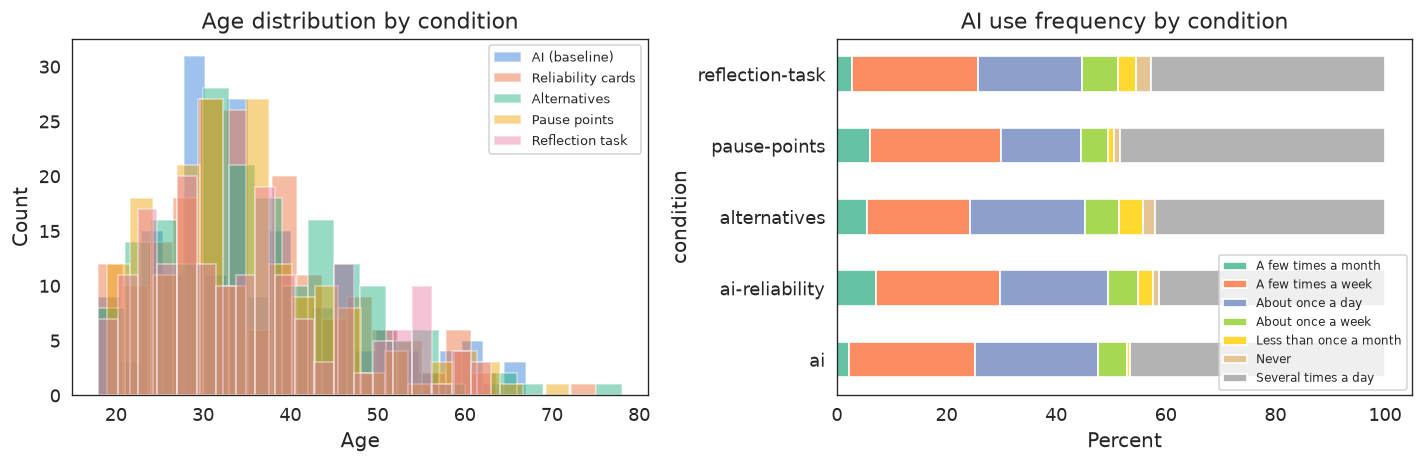

In [9]:
# ---- demographic plot: age distribution -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
ax = axes[0]
for cond in COND_ORDER:
    subset = df[df["condition"] == cond]["age"].dropna()
    ax.hist(subset, bins=20, alpha=0.45, color=COND_COLOURS[cond], label=COND_LABELS[cond])
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.set_title("Age distribution by condition")
ax.legend(fontsize=8)

# AI use frequency
ax = axes[1]
ai_cond = pd.crosstab(df["condition"], df["ai_use_label"], normalize="index") * 100
ai_cond = ai_cond.reindex(COND_ORDER)
ai_cond.plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
ax.set_xlabel("Percent")
ax.set_title("AI use frequency by condition")
ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

---
## Step 6 -- Achieved performance, perceived performance, and overestimation

This is the core analysis section.  For each of the three DVs (actual score,
post-task perceived score, and the signed overestimation gap) we:

1. Report per-condition descriptive statistics.
2. Test whether overestimation differs from zero (one-sample t per condition).
3. Run a one-way Welch ANOVA across conditions.
4. Follow up with all 10 pairwise Welch t-tests + Hedges' g.
5. Compute the Pearson correlation between perceived and achieved within
   each condition (a proxy for individual-difference calibration).

In [10]:
# ---- 6a: Descriptives per condition -----------------------------------------
print("=== 6a: Per-condition descriptives ===\n")
dvs = ["actual_score", "post_with_ai", "diffobjper"]
dv_labels = {"actual_score": "Achieved (0-12)", "post_with_ai": "Perceived (0-12)", "diffobjper": "Overestimation"}

for dv in dvs:
    tbl = df.groupby("condition", observed=False)[dv].agg(["count", "mean", "std", "median"]).round(3)
    tbl.index = [COND_LABELS.get(c, c) for c in tbl.index]
    print(f"\n--- {dv_labels[dv]} ---")
    print(tbl.to_string())

=== 6a: Per-condition descriptives ===


--- Achieved (0-12) ---
                   count   mean    std  median
AI (baseline)        187  5.572  1.811     6.0
Reliability cards    182  5.181  1.630     5.0
Alternatives         181  5.199  1.529     5.0
Pause points         184  4.489  2.003     4.0
Reflection task      183  5.525  1.650     5.0

--- Perceived (0-12) ---
                   count   mean    std  median
AI (baseline)        187  9.695  2.366    10.0
Reliability cards    182  8.225  2.136     8.0
Alternatives         181  7.696  2.216     8.0
Pause points         184  7.766  2.562     8.0
Reflection task      183  9.153  2.539    10.0

--- Overestimation ---
                   count   mean    std  median
AI (baseline)        187  4.123  2.905     4.0
Reliability cards    182  3.044  2.638     3.0
Alternatives         181  2.497  2.564     3.0
Pause points         184  3.277  2.885     3.0
Reflection task      183  3.628  3.044     4.0


In [11]:
# ---- 6b: One-sample t-test: is overestimation != 0? ------------------------
print("=== 6b: One-sample t-test -- diffobjper vs 0 per condition ===\n")
onesamp_rows = []
for cond in COND_ORDER:
    x = df.loc[df["condition"] == cond, "diffobjper"].dropna()
    t, p = scipy.stats.ttest_1samp(x, 0)
    d = x.mean() / x.std()  # Cohen's d (one-sample)
    onesamp_rows.append({
        "Condition": COND_LABELS[cond],
        "n": len(x), "Mean": round(x.mean(), 3), "SD": round(x.std(), 3),
        "t": round(t, 3), "p": fmt_p(p), "sig": sig_stars(p), "d": round(d, 3),
    })
onesamp = pd.DataFrame(onesamp_rows)
print(onesamp.to_string(index=False))

=== 6b: One-sample t-test -- diffobjper vs 0 per condition ===

        Condition   n  Mean    SD      t      p sig     d
    AI (baseline) 187 4.123 2.905 19.405 < .001 *** 1.419
Reliability cards 182 3.044 2.638 15.566 < .001 *** 1.154
     Alternatives 181 2.497 2.564 13.104 < .001 *** 0.974
     Pause points 184 3.277 2.885 15.410 < .001 *** 1.136
  Reflection task 183 3.628 3.044 16.123 < .001 *** 1.192


In [12]:
# ---- 6c: Welch ANOVA for each DV -------------------------------------------
print("=== 6c: Welch ANOVA across conditions ===\n")
for dv in dvs:
    groups = [df.loc[df["condition"] == c, dv].dropna().values for c in COND_ORDER]
    if HAS_PINGOUIN:
        aov = pg.welch_anova(dv=dv, between="condition", data=df)
        F_val = aov["F"].values[0]
        p_val = aov["p_unc"].values[0]
        ddof1 = aov["ddof1"].values[0]
        ddof2 = aov["ddof2"].values[0]
        eta = aov["np2"].values[0] if "np2" in aov.columns else np.nan
        print(f"{dv_labels[dv]:25s}  F({ddof1:.0f},{ddof2:.1f}) = {F_val:.3f},  p = {fmt_p(p_val)} {sig_stars(p_val)},  partial eta2 = {eta:.4f}")
    else:
        F_val, p_val = welch_anova_scipy(groups)
        print(f"{dv_labels[dv]:25s}  F = {F_val:.3f},  p = {fmt_p(p_val)} {sig_stars(p_val)}")

=== 6c: Welch ANOVA across conditions ===

Achieved (0-12)            F(4,455.4) = 9.441,  p = < .001 ***,  partial eta2 = 0.0480
Perceived (0-12)           F(4,455.5) = 25.306,  p = < .001 ***,  partial eta2 = 0.1008
Overestimation             F(4,455.7) = 9.066,  p = < .001 ***,  partial eta2 = 0.0366


In [13]:
# ---- 6d: All 10 pairwise comparisons per DV --------------------------------
print("=== 6d: Pairwise Welch t-tests with Hedges' g ===\n")
for dv in dvs:
    pw = pairwise_welch(df, dv, "condition", COND_ORDER)
    pw["group1"] = pw["group1"].map(COND_LABELS)
    pw["group2"] = pw["group2"].map(COND_LABELS)
    display_cols = ["group1", "group2", "mean1", "mean2", "t", "p", "sig", "g", "g_lo", "g_hi"]
    print(f"\n--- {dv_labels[dv]} ---")
    print(pw[display_cols].round(3).to_string(index=False))

=== 6d: Pairwise Welch t-tests with Hedges' g ===


--- Achieved (0-12) ---
           group1            group2  mean1  mean2      t     p sig      g   g_lo   g_hi
    AI (baseline) Reliability cards  5.572  5.181  2.181 0.030   *  0.226  0.022  0.431
    AI (baseline)      Alternatives  5.572  5.199  2.139 0.033   *  0.222  0.017  0.427
    AI (baseline)      Pause points  5.572  4.489  5.461 0.000 ***  0.566  0.359  0.774
    AI (baseline)   Reflection task  5.572  5.525  0.264 0.792      0.027 -0.176  0.231
Reliability cards      Alternatives  5.181  5.199 -0.106 0.916     -0.011 -0.217  0.195
Reliability cards      Pause points  5.181  4.489  3.628 0.000 ***  0.378  0.171  0.585
Reliability cards   Reflection task  5.181  5.525 -1.999 0.046   * -0.209 -0.415 -0.003
     Alternatives      Pause points  5.199  4.489  3.809 0.000 ***  0.397  0.190  0.604
     Alternatives   Reflection task  5.199  5.525 -1.953 0.052   . -0.204 -0.410  0.002
     Pause points   Reflection task  4.489  

In [14]:
# ---- 6e: Pearson r -- perceived vs achieved per condition -------------------
print("=== 6e: Pearson r(perceived, achieved) per condition ===\n")
corr_rows = []
for cond in COND_ORDER:
    sub = df[df["condition"] == cond]
    r, p = scipy.stats.pearsonr(sub["post_with_ai"], sub["actual_score"])
    corr_rows.append({
        "Condition": COND_LABELS[cond], "n": len(sub),
        "r": round(r, 3), "p": fmt_p(p), "sig": sig_stars(p),
    })
corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))

=== 6e: Pearson r(perceived, achieved) per condition ===

        Condition   n      r     p sig
    AI (baseline) 187  0.051 0.489    
Reliability cards 182  0.037 0.616    
     Alternatives 181  0.100 0.181    
     Pause points 184  0.219 0.003  **
  Reflection task 183 -0.011 0.878    


---
## Step 7 -- Trial-level metacognitive sensitivity

Here we move from participant-level summaries to *trial-level* metrics that
capture how well each participant's confidence tracks their accuracy.  We
compute four indices per participant:

- **Confidence discrimination** (`mean_conf_correct - mean_conf_incorrect`):
  do participants give higher confidence when they are actually right?
- **Type-2 AUROC**: the area under the ROC curve for confidence predicting
  correctness -- a non-parametric sensitivity index (chance = 0.5).
- **Calibration error** (absolute): mean |confidence/100 - accuracy| across
  the participant's 12 trials (lower is better).
- **Brier score**: mean (confidence/100 - correct)^2 (lower is better).

For each index we run an ANOVA across conditions and all pairwise tests.

In [15]:
# ---- 7a: Compute per-participant metacognitive indices ----------------------
def compute_meta_indices(grp):
    """Compute metacognitive indices for a single participant."""
    correct = grp["correct"].values
    conf = grp["confidence"].values
    conf01 = grp["conf01"].values
    n = len(grp)

    # Discrimination
    hi = conf[correct == 1]
    lo = conf[correct == 0]
    disc = np.mean(hi) - np.mean(lo) if len(hi) > 0 and len(lo) > 0 else np.nan

    # AUROC
    a2 = auroc2(conf, correct)

    # Calibration: |confidence - accuracy| per trial, then mean
    cal = np.mean(np.abs(conf01 - correct))

    # Brier score
    brier = np.mean((conf01 - correct) ** 2)

    return pd.Series({
        "discrimination": disc,
        "auroc2": a2,
        "calibration": cal,
        "brier": brier,
        "n_correct": int(correct.sum()),
        "n_incorrect": int((1 - correct).sum()),
    })

meta = trials.groupby(["pid", "condition"]).apply(compute_meta_indices).reset_index()
# Drop participants with all correct or all incorrect (cannot compute discrimination/AUROC)
meta_valid = meta.dropna(subset=["discrimination", "auroc2"]).copy()
print(f"Metacognitive indices computed for {len(meta_valid)} participants (dropped {len(meta) - len(meta_valid)} with all-correct or all-incorrect)")

Metacognitive indices computed for 913 participants (dropped 4 with all-correct or all-incorrect)


In [16]:
# ---- 7b: Descriptives per condition -----------------------------------------
print("=== 7b: Metacognitive indices -- descriptives ===\n")
meta_dvs = ["discrimination", "auroc2", "calibration", "brier"]
meta_labels = {
    "discrimination": "Confidence discrimination",
    "auroc2":         "Type-2 AUROC",
    "calibration":    "Calibration error (abs)",
    "brier":          "Brier score",
}

for mdv in meta_dvs:
    tbl = meta_valid.groupby("condition")[mdv].agg(["count", "mean", "std"]).round(4)
    tbl = tbl.reindex(COND_ORDER)
    tbl.index = [COND_LABELS.get(c, c) for c in tbl.index]
    print(f"\n--- {meta_labels[mdv]} ---")
    print(tbl.to_string())

=== 7b: Metacognitive indices -- descriptives ===


--- Confidence discrimination ---
                   count    mean      std
AI (baseline)        187  2.3368   8.9210
Reliability cards    182  7.7351  12.5264
Alternatives         181  5.5903  13.5884
Pause points         184  3.1362  11.7769
Reflection task      179  2.7513  13.3481

--- Type-2 AUROC ---
                   count    mean     std
AI (baseline)        187  0.5407  0.1724
Reliability cards    182  0.6025  0.1719
Alternatives         181  0.5705  0.1787
Pause points         184  0.5499  0.1617
Reflection task      179  0.5418  0.2508

--- Calibration error (abs) ---
                   count    mean     std
AI (baseline)        187  0.5122  0.1123
Reliability cards    182  0.4933  0.0892
Alternatives         181  0.4968  0.0899
Pause points         184  0.5181  0.1188
Reflection task      179  0.5218  0.1204

--- Brier score ---
                   count    mean     std
AI (baseline)        187  0.3907  0.1422
Reliability 

In [17]:
# ---- 7c: Paired t-test: confidence correct vs incorrect per condition ------
print("=== 7c: Paired t -- confidence(correct) vs confidence(incorrect) ===\n")
paired_rows = []
for cond in COND_ORDER:
    sub = meta_valid[meta_valid["condition"] == cond]
    # We need per-participant mean_conf_correct and mean_conf_incorrect
    # Get from participant CSV
    sub_df = df[df["condition"] == cond]
    cc = sub_df["mean_conf_correct"].dropna()
    ci = sub_df["mean_conf_incorrect"].dropna()
    # Paired -- need participants with both
    sub_both = sub_df.dropna(subset=["mean_conf_correct", "mean_conf_incorrect"])
    if len(sub_both) > 0:
        t, p = scipy.stats.ttest_rel(sub_both["mean_conf_correct"], sub_both["mean_conf_incorrect"])
        diff = (sub_both["mean_conf_correct"] - sub_both["mean_conf_incorrect"]).mean()
        paired_rows.append({
            "Condition": COND_LABELS[cond], "n": len(sub_both),
            "Mean diff": round(diff, 2), "t": round(t, 3),
            "p": fmt_p(p), "sig": sig_stars(p),
        })
paired_df = pd.DataFrame(paired_rows)
print(paired_df.to_string(index=False))

=== 7c: Paired t -- confidence(correct) vs confidence(incorrect) ===

        Condition   n  Mean diff     t      p sig
    AI (baseline) 187       2.34 3.582 < .001 ***
Reliability cards 182       7.74 8.331 < .001 ***
     Alternatives 181       5.59 5.535 < .001 ***
     Pause points 184       3.14 3.612 < .001 ***
  Reflection task 183       2.10 3.044  0.003  **


In [18]:
# ---- 7d: ANOVA + pairwise for each metacognitive index ---------------------
print("=== 7d: Welch ANOVA for metacognitive indices ===\n")
for mdv in meta_dvs:
    groups = [meta_valid.loc[meta_valid["condition"] == c, mdv].dropna().values for c in COND_ORDER]
    F_val, p_val = welch_anova_scipy(groups)
    print(f"{meta_labels[mdv]:30s}  F = {F_val:.3f},  p = {fmt_p(p_val)} {sig_stars(p_val)}")

=== 7d: Welch ANOVA for metacognitive indices ===

Confidence discrimination       F = 6.542,  p = < .001 ***
Type-2 AUROC                    F = 3.452,  p = 0.008 **
Calibration error (abs)         F = 2.577,  p = 0.036 *
Brier score                     F = 5.144,  p = < .001 ***


In [19]:
print("=== 7d (continued): Pairwise tests for metacognitive indices ===\n")
for mdv in meta_dvs:
    pw = pairwise_welch(meta_valid, mdv, "condition", COND_ORDER)
    pw["group1"] = pw["group1"].map(COND_LABELS)
    pw["group2"] = pw["group2"].map(COND_LABELS)
    sig_pw = pw[pw["p"] < 0.10]
    if len(sig_pw) > 0:
        print(f"\n--- {meta_labels[mdv]} (p < .10 only) ---")
        print(sig_pw[["group1", "group2", "mean1", "mean2", "t", "p", "sig", "g"]].round(3).to_string(index=False))
    else:
        print(f"\n--- {meta_labels[mdv]}: no pairwise p < .10 ---")

=== 7d (continued): Pairwise tests for metacognitive indices ===


--- Confidence discrimination (p < .10 only) ---
           group1            group2  mean1  mean2      t     p sig      g
    AI (baseline) Reliability cards  2.337  7.735 -4.757 0.000 *** -0.497
    AI (baseline)      Alternatives  2.337  5.590 -2.706 0.007  ** -0.283
Reliability cards      Pause points  7.735  3.136  3.618 0.000 ***  0.378
Reliability cards   Reflection task  7.735  2.751  3.657 0.000 ***  0.384
     Alternatives      Pause points  5.590  3.136  1.843 0.066   .  0.193
     Alternatives   Reflection task  5.590  2.751  2.000 0.046   *  0.210

--- Type-2 AUROC (p < .10 only) ---
           group1            group2  mean1  mean2      t     p sig      g
    AI (baseline) Reliability cards  0.541  0.603 -3.451 0.001 *** -0.359
Reliability cards      Alternatives  0.603  0.571  1.738 0.083   .  0.182
Reliability cards      Pause points  0.603  0.550  3.015 0.003  **  0.315
Reliability cards   Reflection ta

---
## Step 8 -- Post-task questionnaires

Participants completed several validated questionnaire scales after the
planning tasks.  For each scale we report per-condition descriptives, a
one-way Welch ANOVA, and pairwise comparisons.  Scales:

- **NASA-TLX** (`tlx_mean`): cognitive workload (1-21, lower is less load).
- **Trust** (`trust_mean`): trust in the AI system (1-5, midpoint 3).
- **SUS** (`sus_score`): System Usability Scale (0-100).
- **UEQ-S Overall** (`ueq_overall`): short User Experience Questionnaire (-3 to 3).
- **UEQ-S Pragmatic** (`ueq_pragmatic`): task-oriented quality.
- **UEQ-S Hedonic** (`ueq_hedonic`): pleasure/stimulation quality.
- **NFC** (`nfc_mean`): Need for Cognition (1-5).

For trust we additionally test whether the mean differs from the scale
midpoint of 3 (one-sample t).

In [20]:
# ---- 8a: Questionnaire descriptives ----------------------------------------
print("=== 8a: Questionnaire descriptives by condition ===\n")
q_vars = ["tlx_mean", "trust_mean", "sus_score", "ueq_overall", "ueq_pragmatic", "ueq_hedonic", "nfc_mean"]
q_labels = {
    "tlx_mean":      "NASA-TLX",
    "trust_mean":    "Trust",
    "sus_score":     "SUS",
    "ueq_overall":   "UEQ-S Overall",
    "ueq_pragmatic": "UEQ-S Pragmatic",
    "ueq_hedonic":   "UEQ-S Hedonic",
    "nfc_mean":      "NFC",
}

for qv in q_vars:
    tbl = df.groupby("condition", observed=False)[qv].agg(["count", "mean", "std"]).round(3)
    tbl.index = [COND_LABELS.get(c, c) for c in tbl.index]
    print(f"\n--- {q_labels[qv]} ---")
    print(tbl.to_string())

=== 8a: Questionnaire descriptives by condition ===


--- NASA-TLX ---
                   count    mean    std
AI (baseline)        187   7.672  3.281
Reliability cards    182   9.218  2.892
Alternatives         181   9.517  2.856
Pause points         184   9.673  2.854
Reflection task      183  11.684  3.361

--- Trust ---
                   count   mean    std
AI (baseline)        187  3.777  0.760
Reliability cards    182  3.453  0.773
Alternatives         181  3.150  0.810
Pause points         184  3.260  0.813
Reflection task      183  3.636  0.778

--- SUS ---
                   count    mean     std
AI (baseline)        187  79.505  18.113
Reliability cards    182  74.560  18.131
Alternatives         181  67.459  18.737
Pause points         184  59.864  22.385
Reflection task      183  72.773  17.776

--- UEQ-S Overall ---
                   count   mean    std
AI (baseline)        187  1.306  1.111
Reliability cards    182  1.065  1.082
Alternatives         181  0.804  1.005
Pa

In [21]:
# ---- 8b: Welch ANOVA per questionnaire -------------------------------------
print("=== 8b: Welch ANOVA for questionnaires ===\n")
for qv in q_vars:
    groups = [df.loc[df["condition"] == c, qv].dropna().values for c in COND_ORDER]
    F_val, p_val = welch_anova_scipy(groups)
    print(f"{q_labels[qv]:20s}  F = {F_val:.3f},  p = {fmt_p(p_val)} {sig_stars(p_val)}")

=== 8b: Welch ANOVA for questionnaires ===

NASA-TLX              F = 40.515,  p = < .001 ***
Trust                 F = 19.909,  p = < .001 ***
SUS                   F = 28.407,  p = < .001 ***
UEQ-S Overall         F = 23.876,  p = < .001 ***
UEQ-S Pragmatic       F = 35.120,  p = < .001 ***
UEQ-S Hedonic         F = 9.196,  p = < .001 ***
NFC                   F = 0.754,  p = 0.555  


In [22]:
# ---- 8c: Pairwise tests for questionnaires ---------------------------------
print("=== 8c: Pairwise comparisons (questionnaires) ===\n")
for qv in q_vars:
    pw = pairwise_welch(df, qv, "condition", COND_ORDER)
    pw["group1"] = pw["group1"].map(COND_LABELS)
    pw["group2"] = pw["group2"].map(COND_LABELS)
    sig_pw = pw[pw["p"] < 0.10]
    if len(sig_pw) > 0:
        print(f"\n--- {q_labels[qv]} (p < .10 only) ---")
        print(sig_pw[["group1", "group2", "mean1", "mean2", "t", "p", "sig", "g"]].round(3).to_string(index=False))
    else:
        print(f"\n--- {q_labels[qv]}: no pairwise p < .10 ---")

=== 8c: Pairwise comparisons (questionnaires) ===


--- NASA-TLX (p < .10 only) ---
           group1            group2  mean1  mean2       t   p sig      g
    AI (baseline) Reliability cards  7.672  9.218  -4.804 0.0 *** -0.498
    AI (baseline)      Alternatives  7.672  9.517  -5.758 0.0 *** -0.598
    AI (baseline)      Pause points  7.672  9.673  -6.270 0.0 *** -0.649
    AI (baseline)   Reflection task  7.672 11.684 -11.616 0.0 *** -1.206
Reliability cards   Reflection task  9.218 11.684  -7.515 0.0 *** -0.785
     Alternatives   Reflection task  9.517 11.684  -6.633 0.0 *** -0.693
     Pause points   Reflection task  9.673 11.684  -6.177 0.0 *** -0.644

--- Trust (p < .10 only) ---
           group1            group2  mean1  mean2      t     p sig      g
    AI (baseline) Reliability cards  3.777  3.453  4.060 0.000 ***  0.422
    AI (baseline)      Alternatives  3.777  3.150  7.659 0.000 ***  0.798
    AI (baseline)      Pause points  3.777  3.260  6.334 0.000 ***  0.657
    AI


--- NFC (p < .10 only) ---
       group1          group2  mean1  mean2     t    p sig     g
AI (baseline) Reflection task  3.529   3.37 1.702 0.09   . 0.177


In [23]:
# ---- 8d: Trust -- one-sample t vs midpoint 3 per condition ------------------
print("=== 8d: Trust vs midpoint (3) -- one-sample t ===\n")
trust_rows = []
for cond in COND_ORDER:
    x = df.loc[df["condition"] == cond, "trust_mean"].dropna()
    t, p = scipy.stats.ttest_1samp(x, 3)
    trust_rows.append({
        "Condition": COND_LABELS[cond], "n": len(x),
        "Mean": round(x.mean(), 3), "SD": round(x.std(), 3),
        "t": round(t, 3), "p": fmt_p(p), "sig": sig_stars(p),
    })
trust_df = pd.DataFrame(trust_rows)
print(trust_df.to_string(index=False))

=== 8d: Trust vs midpoint (3) -- one-sample t ===

        Condition   n  Mean    SD      t      p sig
    AI (baseline) 187 3.777 0.760 13.982 < .001 ***
Reliability cards 182 3.453 0.773  7.915 < .001 ***
     Alternatives 181 3.150 0.810  2.490  0.014   *
     Pause points 184 3.260 0.813  4.329 < .001 ***
  Reflection task 183 3.636 0.778 11.059 < .001 ***


---
## Step 9 -- Mediation analysis

We test whether condition effects on overestimation (`diffobjper`) are
mediated by trust and/or hedonic user experience.  The logic:

- **Path a**: Condition (dummies, `ai` = reference) -> mediator (trust_mean_z, ueq_hedonic_z)
- **Path b**: mediator -> diffobjper_z (controlling for condition)
- **Indirect effect**: a * b, bootstrapped for inference (5000 resamples)

We standardise all continuous variables to z-scores and use `statsmodels`
OLS.  We also check collinearity with VIF.

In [24]:
# ---- 9a: Prepare variables -------------------------------------------------
df["trust_mean_z"]    = (df["trust_mean"] - df["trust_mean"].mean()) / df["trust_mean"].std()
df["ueq_hedonic_z"]   = (df["ueq_hedonic"] - df["ueq_hedonic"].mean()) / df["ueq_hedonic"].std()
df["diffobjper_z"]    = (df["diffobjper"] - df["diffobjper"].mean()) / df["diffobjper"].std()

# Create dummy variables (ai = reference) with clean names for patsy
dummy_map = {
    "ai-reliability":  "cond_reliability",
    "alternatives":    "cond_alternatives",
    "pause-points":    "cond_pausepoints",
    "reflection-task": "cond_reflection",
}
for cond, col in dummy_map.items():
    df[col] = (df["condition"] == cond).astype(float)

dummy_cols = list(dummy_map.values())
dummy_formula_part = " + ".join(dummy_cols)
print("Condition dummies (ai = reference):", dummy_cols)
print(f"Sample size for mediation: {len(df)}")

Condition dummies (ai = reference): ['cond_reliability', 'cond_alternatives', 'cond_pausepoints', 'cond_reflection']
Sample size for mediation: 917


In [25]:
# ---- 9b: Path a -- condition -> mediators -----------------------------------
print("=== 9b: Path a -- Condition -> Mediators ===\n")
for mediator in ["trust_mean_z", "ueq_hedonic_z"]:
    formula_a = f"{mediator} ~ {dummy_formula_part}"
    model_a = smf.ols(formula_a, data=df).fit()
    print(f"\n--- {mediator} ---")
    print(model_a.summary2().tables[1][["Coef.", "Std.Err.", "t", "P>|t|"]].round(4).to_string())

=== 9b: Path a -- Condition -> Mediators ===


--- trust_mean_z ---
                    Coef.  Std.Err.       t   P>|t|
Intercept          0.3913    0.0703  5.5671  0.0000
cond_reliability  -0.3959    0.1001 -3.9557  0.0001
cond_alternatives -0.7665    0.1002 -7.6484  0.0000
cond_pausepoints  -0.6326    0.0998 -6.3383  0.0000
cond_reflection   -0.1728    0.0999 -1.7291  0.0841

--- ueq_hedonic_z ---
                    Coef.  Std.Err.       t   P>|t|
Intercept          0.2768    0.0719  3.8519  0.0001
cond_reliability  -0.1748    0.1023 -1.7085  0.0879
cond_alternatives -0.2440    0.1025 -2.3812  0.0175
cond_pausepoints  -0.5785    0.1020 -5.6699  0.0000
cond_reflection   -0.3901    0.1022 -3.8180  0.0001


In [26]:
# ---- 9c: Path b + c' -- mediators + condition -> diffobjper -----------------
print("=== 9c: Path b + c' -- Full model (mediators + condition -> diffobjper_z) ===\n")
formula_full = f"diffobjper_z ~ trust_mean_z + ueq_hedonic_z + {dummy_formula_part}"
model_full = smf.ols(formula_full, data=df).fit()
print(model_full.summary2().tables[1][["Coef.", "Std.Err.", "t", "P>|t|"]].round(4).to_string())
print(f"\nR-squared: {model_full.rsquared:.4f},  Adj. R-squared: {model_full.rsquared_adj:.4f}")
print(f"F({model_full.df_model:.0f},{model_full.df_resid:.0f}) = {model_full.fvalue:.3f}, p = {fmt_p(model_full.f_pvalue)}")

=== 9c: Path b + c' -- Full model (mediators + condition -> diffobjper_z) ===

                    Coef.  Std.Err.        t   P>|t|
Intercept          0.1230    0.0675   1.8240  0.0685
trust_mean_z       0.3812    0.0371  10.2828  0.0000
ueq_hedonic_z      0.0313    0.0363   0.8633  0.3882
cond_reliability  -0.2208    0.0952  -2.3186  0.0206
cond_alternatives -0.2685    0.0977  -2.7467  0.0061
cond_pausepoints  -0.0364    0.0966  -0.3772  0.7061
cond_reflection   -0.0948    0.0950  -0.9975  0.3188

R-squared: 0.1833,  Adj. R-squared: 0.1779
F(6,910) = 34.036, p = < .001


In [27]:
# ---- 9d: Bootstrapped indirect effects -------------------------------------
print("=== 9d: Bootstrapped indirect effects (5000 resamples) ===\n")
np.random.seed(42)
n_boot = 5000

# For each dummy: indirect = a_coef * b_coef
mediators = ["trust_mean_z", "ueq_hedonic_z"]
indirect_results = []

for dummy in dummy_cols:
    for mediator in mediators:
        boot_indirect = []
        for _ in range(n_boot):
            idx = np.random.choice(len(df), size=len(df), replace=True)
            boot_df = df.iloc[idx]
            # Path a
            X_a = sm.add_constant(boot_df[dummy_cols])
            y_a = boot_df[mediator]
            try:
                a_coef = sm.OLS(y_a, X_a).fit().params[dummy]
            except Exception:
                continue
            # Path b
            X_b = sm.add_constant(boot_df[mediators + dummy_cols])
            y_b = boot_df["diffobjper_z"]
            try:
                b_coef = sm.OLS(y_b, X_b).fit().params[mediator]
            except Exception:
                continue
            boot_indirect.append(a_coef * b_coef)

        boot_indirect = np.array(boot_indirect)
        ci_lo, ci_hi = np.percentile(boot_indirect, [2.5, 97.5])
        mean_ind = np.mean(boot_indirect)
        sig = "*" if (ci_lo > 0 or ci_hi < 0) else " "

        indirect_results.append({
            "Condition dummy": dummy,
            "Mediator": mediator,
            "Indirect (mean)": round(mean_ind, 4),
            "CI 2.5%": round(ci_lo, 4),
            "CI 97.5%": round(ci_hi, 4),
            "Sig": sig,
        })

ind_df = pd.DataFrame(indirect_results)
print(ind_df.to_string(index=False))

=== 9d: Bootstrapped indirect effects (5000 resamples) ===



  Condition dummy      Mediator  Indirect (mean)  CI 2.5%  CI 97.5% Sig
 cond_reliability  trust_mean_z          -0.1501  -0.2283   -0.0766   *
 cond_reliability ueq_hedonic_z          -0.0057  -0.0247    0.0073    
cond_alternatives  trust_mean_z          -0.2904  -0.3847   -0.2042   *
cond_alternatives ueq_hedonic_z          -0.0077  -0.0310    0.0100    
 cond_pausepoints  trust_mean_z          -0.2412  -0.3318   -0.1588   *
 cond_pausepoints ueq_hedonic_z          -0.0176  -0.0638    0.0238    
  cond_reflection  trust_mean_z          -0.0663  -0.1416    0.0064    
  cond_reflection ueq_hedonic_z          -0.0121  -0.0455    0.0153    


In [28]:
# ---- 9e: Single-mediator sensitivity models ---------------------------------
print("=== 9e: Single-mediator models (sensitivity) ===\n")
for mediator in mediators:
    formula_single = f"diffobjper_z ~ {mediator} + {dummy_formula_part}"
    model_s = smf.ols(formula_single, data=df).fit()
    print(f"\n--- Mediator: {mediator} only ---")
    print(model_s.summary2().tables[1][["Coef.", "Std.Err.", "t", "P>|t|"]].round(4).to_string())
    print(f"R-squared: {model_s.rsquared:.4f}")

=== 9e: Single-mediator models (sensitivity) ===


--- Mediator: trust_mean_z only ---
                    Coef.  Std.Err.        t   P>|t|
Intercept          0.1250    0.0674   1.8537  0.0641
trust_mean_z       0.3984    0.0312  12.7550  0.0000
cond_reliability  -0.2195    0.0952  -2.3051  0.0214
cond_alternatives -0.2629    0.0975  -2.6960  0.0071
cond_pausepoints  -0.0436    0.0962  -0.4537  0.6502
cond_reflection   -0.1040    0.0944  -1.1018  0.2708
R-squared: 0.1826

--- Mediator: ueq_hedonic_z only ---
                    Coef.  Std.Err.       t   P>|t|
Intercept          0.2166    0.0706  3.0693  0.0022
ueq_hedonic_z      0.2320    0.0323  7.1909  0.0000
cond_reliability  -0.3366    0.0998 -3.3712  0.0008
cond_alternatives -0.5117    0.1001 -5.1095  0.0000
cond_pausepoints  -0.1614    0.1012 -1.5959  0.1109
cond_reflection   -0.0824    0.1003 -0.8209  0.4119
R-squared: 0.0884


In [29]:
# ---- 9f: Collinearity diagnostics (VIF) ------------------------------------
print("=== 9f: Variance Inflation Factors ===\n")
X_full = df[mediators + dummy_cols].copy()
X_full = sm.add_constant(X_full)
vif_data = pd.DataFrame({
    "Variable": X_full.columns[1:],
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(1, X_full.shape[1])],
}).round(3)
print(vif_data.to_string(index=False))

=== 9f: Variance Inflation Factors ===

         Variable   VIF
     trust_mean_z 1.531
    ueq_hedonic_z 1.465
 cond_reliability 1.609
cond_alternatives 1.688
 cond_pausepoints 1.668
  cond_reflection 1.609


---
## Step 10 -- Figures

Four publication-quality plots using the study's colourblind-safe palette:

1. **Raincloud plot**: actual score distribution by condition.
2. **Grouped bars**: achieved vs perceived scores side by side.
3. **Overestimation bars**: signed gap with standard-error bars.
4. **Calibration scatter**: perceived vs achieved, faceted by condition,
   with a perfect-calibration diagonal.

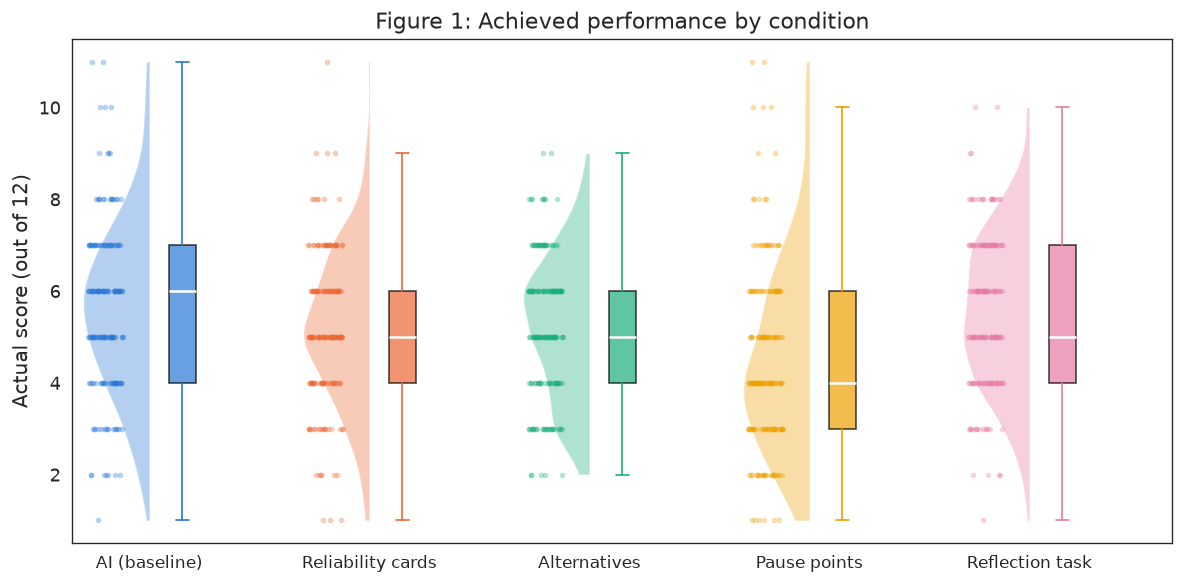

In [30]:
# ---- Figure 1: Raincloud -- actual score by condition -----------------------
fig, ax = plt.subplots(figsize=(10, 5))

positions = list(range(len(COND_ORDER)))
for i, cond in enumerate(COND_ORDER):
    data = df.loc[df["condition"] == cond, "actual_score"].dropna().values
    colour = COND_COLOURS[cond]

    # Violin (half)
    parts = ax.violinplot([data], positions=[i], showmeans=False,
                          showmedians=False, showextrema=False, widths=0.6)
    for pc in parts["bodies"]:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], -np.inf, m)
        pc.set_facecolor(colour)
        pc.set_alpha(0.35)

    # Box
    bp = ax.boxplot([data], positions=[i + 0.15], widths=0.12,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor=colour, alpha=0.7),
                    medianprops=dict(color="white", linewidth=1.5),
                    whiskerprops=dict(color=colour), capprops=dict(color=colour))

    # Strip (jitter)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(data))
    ax.scatter(np.full(len(data), i - 0.2) + jitter, data,
               s=6, alpha=0.25, color=colour, zorder=2)

ax.set_xticks(positions)
ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER], fontsize=10)
ax.set_ylabel("Actual score (out of 12)")
ax.set_title("Figure 1: Achieved performance by condition")
plt.tight_layout()
plt.show()

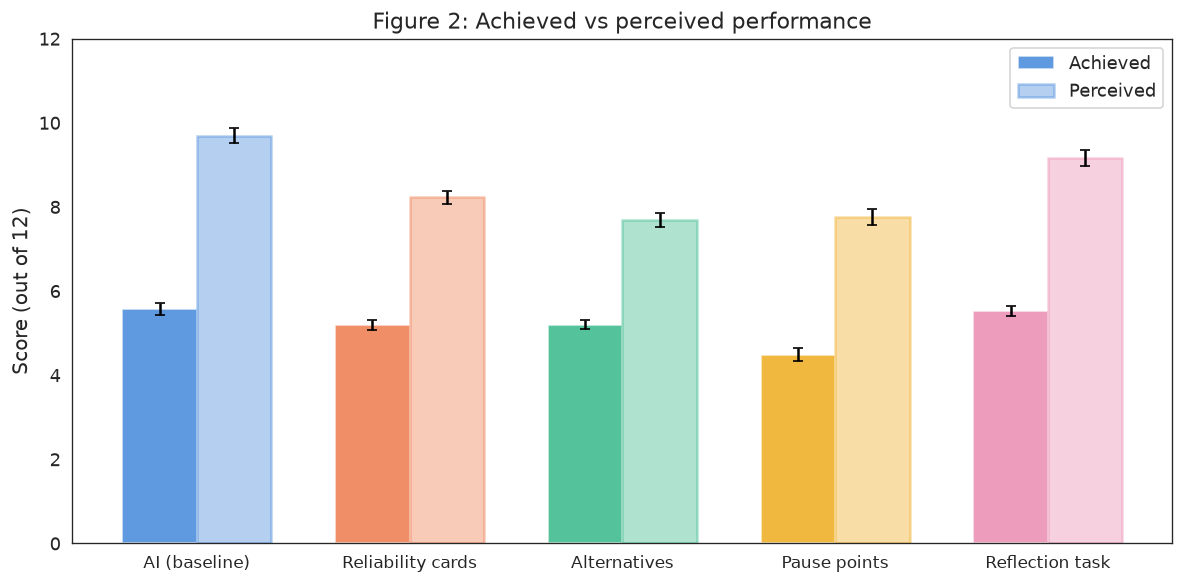

In [31]:
# ---- Figure 2: Grouped bars -- achieved vs perceived ------------------------
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(COND_ORDER))
width = 0.35

achieved_means = [df.loc[df["condition"] == c, "actual_score"].mean() for c in COND_ORDER]
achieved_ses   = [df.loc[df["condition"] == c, "actual_score"].sem() for c in COND_ORDER]
perceived_means = [df.loc[df["condition"] == c, "post_with_ai"].mean() for c in COND_ORDER]
perceived_ses   = [df.loc[df["condition"] == c, "post_with_ai"].sem() for c in COND_ORDER]

bars1 = ax.bar(x - width / 2, achieved_means, width, yerr=achieved_ses,
               color=[COND_COLOURS[c] for c in COND_ORDER], alpha=0.75,
               label="Achieved", edgecolor="white", capsize=3)
bars2 = ax.bar(x + width / 2, perceived_means, width, yerr=perceived_ses,
               color=[COND_COLOURS[c] for c in COND_ORDER], alpha=0.35,
               label="Perceived", edgecolor=[COND_COLOURS[c] for c in COND_ORDER],
               linewidth=1.5, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER], fontsize=10)
ax.set_ylabel("Score (out of 12)")
ax.set_ylim(0, 12)
ax.legend()
ax.set_title("Figure 2: Achieved vs perceived performance")
plt.tight_layout()
plt.show()

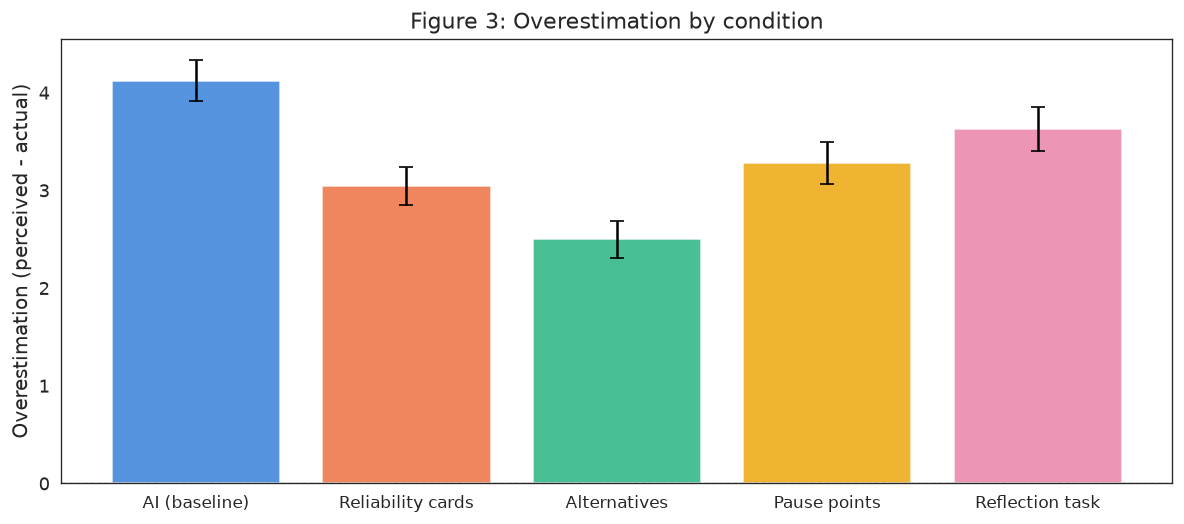

In [32]:
# ---- Figure 3: Overestimation bars with SE ----------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

oe_means = [df.loc[df["condition"] == c, "diffobjper"].mean() for c in COND_ORDER]
oe_ses   = [df.loc[df["condition"] == c, "diffobjper"].sem() for c in COND_ORDER]

bars = ax.bar(range(len(COND_ORDER)), oe_means, yerr=oe_ses,
              color=[COND_COLOURS[c] for c in COND_ORDER], alpha=0.8,
              edgecolor="white", capsize=4)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(COND_ORDER)))
ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER], fontsize=10)
ax.set_ylabel("Overestimation (perceived - actual)")
ax.set_title("Figure 3: Overestimation by condition")
plt.tight_layout()
plt.show()

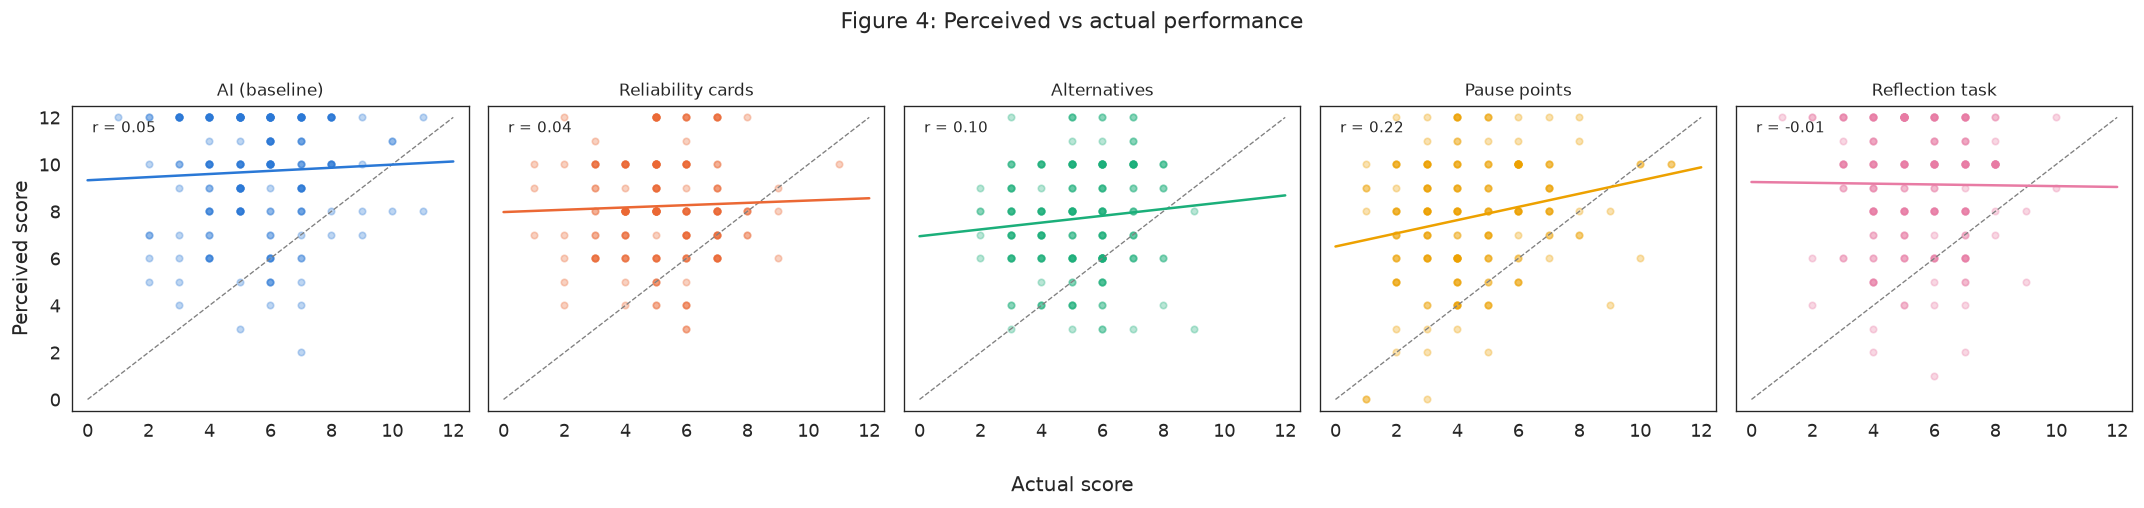

In [33]:
# ---- Figure 4: Scatter -- perceived vs achieved, faceted --------------------
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)

for i, cond in enumerate(COND_ORDER):
    ax = axes[i]
    sub = df[df["condition"] == cond]
    ax.scatter(sub["actual_score"], sub["post_with_ai"],
               alpha=0.3, s=15, color=COND_COLOURS[cond])
    ax.plot([0, 12], [0, 12], "--", color="grey", linewidth=0.8, label="Perfect calibration")
    # Regression line
    slope, intercept, r, p, se = scipy.stats.linregress(sub["actual_score"], sub["post_with_ai"])
    xs = np.linspace(0, 12, 100)
    ax.plot(xs, intercept + slope * xs, color=COND_COLOURS[cond], linewidth=1.5)
    ax.set_title(COND_LABELS[cond], fontsize=10)
    ax.set_xlim(-0.5, 12.5)
    ax.set_ylim(-0.5, 12.5)
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, fontsize=9, va="top")
    if i == 0:
        ax.set_ylabel("Perceived score")

fig.supxlabel("Actual score", fontsize=12)
fig.suptitle("Figure 4: Perceived vs actual performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 11 -- Confirmatory hypothesis tests

The pre-registered directional hypotheses test each of the four
interventions against the AI baseline on three outcomes:

1. **Absolute estimation error** -- intervention < baseline (less
   miscalibration is better).
2. **Confidence discrimination** -- intervention > baseline (higher
   sensitivity is better).
3. **Actual score** -- intervention > baseline (better performance is
   better).

Each comparison uses a one-sided Welch t-test.  Within each outcome family
(4 tests) we apply Holm correction.  We report Hedges' g with 95% CI.

In [34]:
# ---- 11a: Directional Welch t-tests per hypothesis -------------------------
print("=== Step 11: Confirmatory hypothesis tests ===\n")

hypothesis_rows = []
baseline_data = {}
baseline_data["absolute_estimation_error"] = df.loc[df["condition"] == "ai", "absolute_estimation_error"].dropna()
baseline_data["confidence_discrimination"] = df.loc[df["condition"] == "ai", "confidence_discrimination"].dropna()
baseline_data["actual_score"] = df.loc[df["condition"] == "ai", "actual_score"].dropna()

interventions = ["ai-reliability", "alternatives", "pause-points", "reflection-task"]

for dv, direction, alt in [
    ("absolute_estimation_error", "less",    "less"),     # intervention < baseline
    ("confidence_discrimination", "greater", "greater"),  # intervention > baseline
    ("actual_score",              "greater", "greater"),  # intervention > baseline
]:
    family_ps = []
    family_rows = []
    for cond in interventions:
        x_int = df.loc[df["condition"] == cond, dv].dropna()
        x_base = baseline_data[dv]
        t, p_two = scipy.stats.ttest_ind(x_int, x_base, equal_var=False)
        # One-sided p
        if alt == "less":
            p_one = scipy.stats.t.cdf(t, df=min(len(x_int), len(x_base)) - 1)
        else:  # greater
            p_one = scipy.stats.t.sf(t, df=min(len(x_int), len(x_base)) - 1)
        # More precise one-sided from scipy
        # Use the actual Welch df
        t_stat, p_two_actual = scipy.stats.ttest_ind(x_int, x_base, equal_var=False, alternative=alt)
        p_one = p_two_actual

        g, g_lo, g_hi = hedges_g_ci(x_int.values, x_base.values)
        family_ps.append(p_one)
        family_rows.append({
            "DV": dv, "Intervention": COND_LABELS[cond],
            "n_int": len(x_int), "n_base": len(x_base),
            "mean_int": round(x_int.mean(), 3), "mean_base": round(x_base.mean(), 3),
            "t": round(t_stat, 3), "p_one": p_one,
            "g": round(g, 3), "g_lo": round(g_lo, 3), "g_hi": round(g_hi, 3),
            "direction": direction,
        })

    # Holm correction within family
    sorted_idx = np.argsort(family_ps)
    k = len(family_ps)
    holm_ps = np.ones(k)
    for rank, idx in enumerate(sorted_idx):
        holm_ps[idx] = min(family_ps[idx] * (k - rank), 1.0)
    # Enforce monotonicity
    for rank in range(1, k):
        idx = sorted_idx[rank]
        prev_idx = sorted_idx[rank - 1]
        holm_ps[idx] = max(holm_ps[idx], holm_ps[prev_idx])

    for j, row in enumerate(family_rows):
        row["p_holm"] = holm_ps[j]
        row["sig_raw"] = sig_stars(row["p_one"])
        row["sig_holm"] = sig_stars(row["p_holm"])
        hypothesis_rows.append(row)

hyp_df = pd.DataFrame(hypothesis_rows)
print("Directional tests with Holm correction:\n")
display_cols = ["DV", "Intervention", "mean_int", "mean_base", "t", "p_one", "sig_raw", "p_holm", "sig_holm", "g", "g_lo", "g_hi"]
for dv_name in ["absolute_estimation_error", "confidence_discrimination", "actual_score"]:
    print(f"\n--- {dv_name} ---")
    sub = hyp_df[hyp_df["DV"] == dv_name][display_cols].copy()
    sub["p_one"] = sub["p_one"].apply(fmt_p)
    sub["p_holm"] = sub["p_holm"].apply(fmt_p)
    print(sub.to_string(index=False))

=== Step 11: Confirmatory hypothesis tests ===

Directional tests with Holm correction:


--- absolute_estimation_error ---
                       DV      Intervention  mean_int  mean_base      t  p_one sig_raw p_holm sig_holm      g   g_lo   g_hi
absolute_estimation_error Reliability cards     3.352      4.422 -4.418 < .001     *** < .001      *** -0.459 -0.665 -0.252
absolute_estimation_error      Alternatives     2.961      4.422 -6.309 < .001     *** < .001      *** -0.655 -0.864 -0.445
absolute_estimation_error      Pause points     3.614      4.422 -3.197 < .001     ***  0.002       ** -0.331 -0.536 -0.126
absolute_estimation_error   Reflection task     4.033      4.422 -1.528  0.064       .  0.064        . -0.159 -0.363  0.045

--- confidence_discrimination ---
                       DV      Intervention  mean_int  mean_base      t  p_one sig_raw p_holm sig_holm      g   g_lo  g_hi
confidence_discrimination Reliability cards     7.735      2.337  4.757 < .001     *** < .001     

In [35]:
# ---- 11b: Verdict table ----------------------------------------------------
print("\n=== Verdict table ===\n")
verdict_rows = []
for _, row in hyp_df.iterrows():
    supported = row["p_holm"] < 0.05
    # Check direction is correct
    if row["direction"] == "less":
        direction_ok = row["mean_int"] < row["mean_base"]
    else:
        direction_ok = row["mean_int"] > row["mean_base"]
    verdict = "Supported" if (supported and direction_ok) else "Not supported"
    verdict_rows.append({
        "Hypothesis": f"{row['Intervention']} vs baseline",
        "DV": row["DV"],
        "Direction": row["direction"],
        "p (Holm)": fmt_p(row["p_holm"]),
        "g": row["g"],
        "Verdict": verdict,
    })
verdict_df = pd.DataFrame(verdict_rows)
print(verdict_df.to_string(index=False))


=== Verdict table ===

                   Hypothesis                        DV Direction p (Holm)      g       Verdict
Reliability cards vs baseline absolute_estimation_error      less   < .001 -0.459     Supported
     Alternatives vs baseline absolute_estimation_error      less   < .001 -0.655     Supported
     Pause points vs baseline absolute_estimation_error      less    0.002 -0.331     Supported
  Reflection task vs baseline absolute_estimation_error      less    0.064 -0.159 Not supported
Reliability cards vs baseline confidence_discrimination   greater   < .001  0.497     Supported
     Alternatives vs baseline confidence_discrimination   greater    0.011  0.283     Supported
     Pause points vs baseline confidence_discrimination   greater    0.462  0.076 Not supported
  Reflection task vs baseline confidence_discrimination   greater    0.597 -0.026 Not supported
Reliability cards vs baseline              actual_score   greater    1.000 -0.226 Not supported
     Alternative

---
## Step 12 -- Wave sensitivity

Data were collected in two waves:

- **Wave 1** (July 2026): `ai` and `ai-reliability`
- **Wave 2** (August 2026): `ai`, `alternatives`, `pause-points`, `reflection-task`

The `ai` baseline was collected in both waves.  To check whether wave
membership confounds the results, we:

1. Compare the wave-1 and wave-2 `ai` groups on key DVs.
2. Run the within-wave-2 comparisons (all 4 conditions collected
   simultaneously) to rule out cross-wave confounds.

In [36]:
# ---- 12a: Wave composition -------------------------------------------------
print("=== 12a: Wave composition ===\n")
wave_tab = pd.crosstab(df["condition"], df["wave"])
print(wave_tab.to_string())

=== 12a: Wave composition ===

wave               1    2
condition                
ai               182    5
ai-reliability   182    0
alternatives       0  181
pause-points       0  184
reflection-task    0  183


In [37]:
# ---- 12b: AI baseline across waves -----------------------------------------
print("\n=== 12b: AI baseline -- wave 1 vs wave 2 ===\n")
ai_w1 = df[(df["condition"] == "ai") & (df["wave"] == 1)]
ai_w2 = df[(df["condition"] == "ai") & (df["wave"] == 2)]
print(f"  AI wave 1: n = {len(ai_w1)}")
print(f"  AI wave 2: n = {len(ai_w2)}")

if len(ai_w1) > 0 and len(ai_w2) > 0:
    for dv in ["actual_score", "post_with_ai", "diffobjper", "mean_confidence"]:
        x1 = ai_w1[dv].dropna()
        x2 = ai_w2[dv].dropna()
        t, p = scipy.stats.ttest_ind(x1, x2, equal_var=False)
        g, gl, gh = hedges_g_ci(x1.values, x2.values)
        print(f"  {dv:30s}  M1={x1.mean():.2f}  M2={x2.mean():.2f}  t={t:.3f}  p={fmt_p(p)} {sig_stars(p)}  g={g:.3f}")
else:
    print("  Note: AI baseline may not be present in both waves.")
    print("  Checking wave values:", df[df["condition"] == "ai"]["wave"].value_counts().to_dict())


=== 12b: AI baseline -- wave 1 vs wave 2 ===

  AI wave 1: n = 182
  AI wave 2: n = 5
  actual_score                    M1=5.58  M2=5.20  t=0.439  p=0.682    g=0.210
  post_with_ai                    M1=9.76  M2=7.40  t=1.716  p=0.159    g=1.003
  diffobjper                      M1=4.18  M2=2.20  t=2.098  p=0.097 .  g=0.680
  mean_confidence                 M1=79.20  M2=73.95  t=0.681  p=0.532    g=0.334


In [38]:
# ---- 12c: Within-wave-2 analysis -------------------------------------------
print("\n=== 12c: Within-wave-2 analysis ===\n")
w2 = df[df["wave"] == 2].copy()
w2_conds = [c for c in COND_ORDER if c in w2["condition"].unique()]
print(f"Wave 2 conditions: {w2_conds}")
print(f"Wave 2 sample: {len(w2)}")
print(w2["condition"].value_counts().reindex(w2_conds).to_frame("n"))
print()

for dv in ["actual_score", "diffobjper", "absolute_estimation_error", "confidence_discrimination"]:
    groups = [w2.loc[w2["condition"] == c, dv].dropna().values for c in w2_conds]
    F_val, p_val = welch_anova_scipy(groups)
    print(f"  {dv:35s}  F = {F_val:.3f},  p = {fmt_p(p_val)} {sig_stars(p_val)}")

# Within-wave-2 pairwise for overestimation
print("\n  Pairwise (diffobjper) within wave 2:")
pw_w2 = pairwise_welch(w2, "diffobjper", "condition", w2_conds)
pw_w2["group1"] = pw_w2["group1"].map(COND_LABELS)
pw_w2["group2"] = pw_w2["group2"].map(COND_LABELS)
print(pw_w2[["group1", "group2", "mean1", "mean2", "t", "p", "sig", "g"]].round(3).to_string(index=False))


=== 12c: Within-wave-2 analysis ===

Wave 2 conditions: ['ai', 'alternatives', 'pause-points', 'reflection-task']
Wave 2 sample: 553
                   n
condition           
ai                 5
alternatives     181
pause-points     184
reflection-task  183

  actual_score                         F = 11.318,  p = < .001 ***
  diffobjper                           F = 5.239,  p = 0.001 **
  absolute_estimation_error            F = 6.856,  p = < .001 ***
  confidence_discrimination            F = 2.868,  p = 0.036 *

  Pairwise (diffobjper) within wave 2:
       group1          group2  mean1  mean2      t     p sig      g
AI (baseline)    Alternatives  2.200  2.497 -0.318 0.766     -0.116
AI (baseline)    Pause points  2.200  3.277 -1.145 0.310     -0.374
AI (baseline) Reflection task  2.200  3.628 -1.514 0.197     -0.470
 Alternatives    Pause points  2.497  3.277 -2.731 0.007  ** -0.285
 Alternatives Reflection task  2.497  3.628 -3.836 0.000 *** -0.401
 Pause points Reflection task  

---
## Step 13 -- Summary statistics card

A comprehensive printout of every key number at full precision for the
manuscript Methods and Results sections.

In [39]:
print("=" * 70)
print("SUMMARY STATISTICS CARD")
print("=" * 70)

print(f"\n--- Sample ---")
print(f"Total recruited:    {len(df_all)}")
print(f"Excluded (primary): {df_all['exclude_primary'].sum()}")
print(f"Analysis sample:    {len(df)}")
for cond in COND_ORDER:
    n_c = (df["condition"] == cond).sum()
    print(f"  {COND_LABELS[cond]:25s}  n = {n_c}")

print(f"\n--- Demographics ---")
print(f"Age: M = {df['age'].mean():.2f}, SD = {df['age'].std():.2f}, range = {df['age'].min():.0f}-{df['age'].max():.0f}")
for g in df["gender"].value_counts().index:
    n = (df["gender"] == g).sum()
    pct = n / len(df) * 100
    print(f"  {g}: {n} ({pct:.1f}%)")

print(f"\n--- Achieved performance ---")
print(f"Overall: M = {df['actual_score'].mean():.4f}, SD = {df['actual_score'].std():.4f}")
for cond in COND_ORDER:
    x = df.loc[df["condition"] == cond, "actual_score"]
    print(f"  {COND_LABELS[cond]:25s}  M = {x.mean():.4f}, SD = {x.std():.4f}")

print(f"\n--- Perceived performance (post_with_ai) ---")
print(f"Overall: M = {df['post_with_ai'].mean():.4f}, SD = {df['post_with_ai'].std():.4f}")
for cond in COND_ORDER:
    x = df.loc[df["condition"] == cond, "post_with_ai"]
    print(f"  {COND_LABELS[cond]:25s}  M = {x.mean():.4f}, SD = {x.std():.4f}")

print(f"\n--- Overestimation (diffobjper) ---")
print(f"Overall: M = {df['diffobjper'].mean():.4f}, SD = {df['diffobjper'].std():.4f}")
for cond in COND_ORDER:
    x = df.loc[df["condition"] == cond, "diffobjper"]
    print(f"  {COND_LABELS[cond]:25s}  M = {x.mean():.4f}, SD = {x.std():.4f}")

print(f"\n--- Confidence ---")
print(f"Mean confidence: M = {df['mean_confidence'].mean():.4f}, SD = {df['mean_confidence'].std():.4f}")
print(f"Confidence discrimination: M = {df['confidence_discrimination'].mean():.4f}, SD = {df['confidence_discrimination'].std():.4f}")

print(f"\n--- Questionnaires ---")
for qv in q_vars:
    print(f"{q_labels[qv]:20s}  M = {df[qv].mean():.4f}, SD = {df[qv].std():.4f}")

print(f"\n--- Completion time ---")
print(f"Minutes: M = {df['completion_minutes'].mean():.2f}, SD = {df['completion_minutes'].std():.2f}, Mdn = {df['completion_minutes'].median():.2f}")

print(f"\n--- Prompting behaviour ---")
print(f"Total prompts: M = {df['total_prompts'].mean():.2f}, SD = {df['total_prompts'].std():.2f}")
print(f"Prompts per task: M = {df['prompts_per_task'].mean():.2f}, SD = {df['prompts_per_task'].std():.2f}")

print("\n" + "=" * 70)
print("END OF ANALYSIS")
print("=" * 70)

SUMMARY STATISTICS CARD

--- Sample ---
Total recruited:    925
Excluded (primary): 8
Analysis sample:    917
  AI (baseline)              n = 187
  Reliability cards          n = 182
  Alternatives               n = 181
  Pause points               n = 184
  Reflection task            n = 183

--- Demographics ---
Age: M = 35.66, SD = 10.92, range = 18-78
  Woman: 466 (50.8%)
  Man: 442 (48.2%)
  Non-binary: 5 (0.5%)
  Prefer not to disclose: 4 (0.4%)

--- Achieved performance ---
Overall: M = 5.1941, SD = 1.7730
  AI (baseline)              M = 5.5722, SD = 1.8106
  Reliability cards          M = 5.1813, SD = 1.6302
  Alternatives               M = 5.1989, SD = 1.5291
  Pause points               M = 4.4891, SD = 2.0027
  Reflection task            M = 5.5246, SD = 1.6502

--- Perceived performance (post_with_ai) ---
Overall: M = 8.5136, SD = 2.4948
  AI (baseline)              M = 9.6952, SD = 2.3665
  Reliability cards          M = 8.2253, SD = 2.1359
  Alternatives               M